--- BẮT ĐẦU XỬ LÝ DỮ LIỆU CHO POSTER ---
✅ Đã tải 162 tuyến xe buýt.
✅ Đã tải 1472 địa điểm du lịch từ 63 tỉnh/thành.

--- [BUS DATA SAMPLE] ---
|   RouteNo | RouteName                              |   Distance_KM |
|----------:|:---------------------------------------|--------------:|
|        01 | Bến Thành - Bến xe buýt Chợ Lớn        |          8.59 |
|        03 | Bến Thành - Thạnh Xuân                 |         20.6  |
|        04 | Bến Thành - Cộng Hòa - Bến xe An Sương |         16.42 |
|        05 | Bến xe buýt Chợ Lớn - Bến xe Biên Hòa  |         38    |
|        06 | Bến xe buýt Chợ Lớn - Đại học Nông Lâm |         26.5  |

--- [TOURISM DATA SAMPLE] ---
| Province   | SpotName                 | Type   |
|:-----------|:-------------------------|:-------|
| HÀ NỘI     | HÀ NỘI                   | Place  |
| HÀ NỘI     | LỜI NHÀ XUẤT BẢN         | Place  |
| HÀ NỘI     | I. NHỮNG CON SỐ ĐÁNG NHỚ | Place  |
| HÀ NỘI     | II. VỊ TRÍ ĐỊA LÝ        | Place  |
| HÀ NỘI     | III. Đ

C:\Users\tuand\AppData\Local\Temp\ipykernel_23236\3611070096.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_provinces, x='Count', y='Province', palette='viridis')


📸 Đã lưu biểu đồ: chart_tourism_stats.png
📸 Đã lưu biểu đồ: chart_tourism_types.png
--- HOÀN TẤT ---


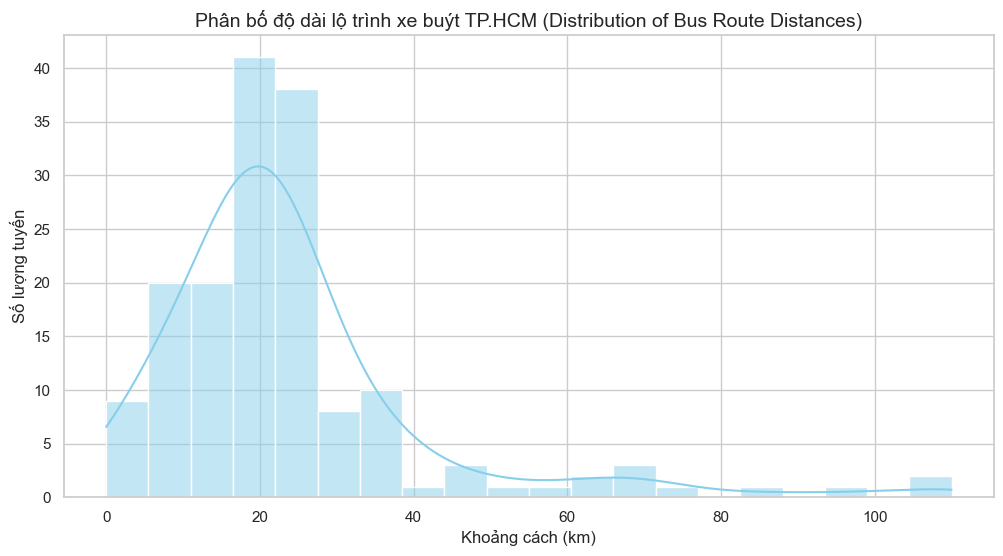

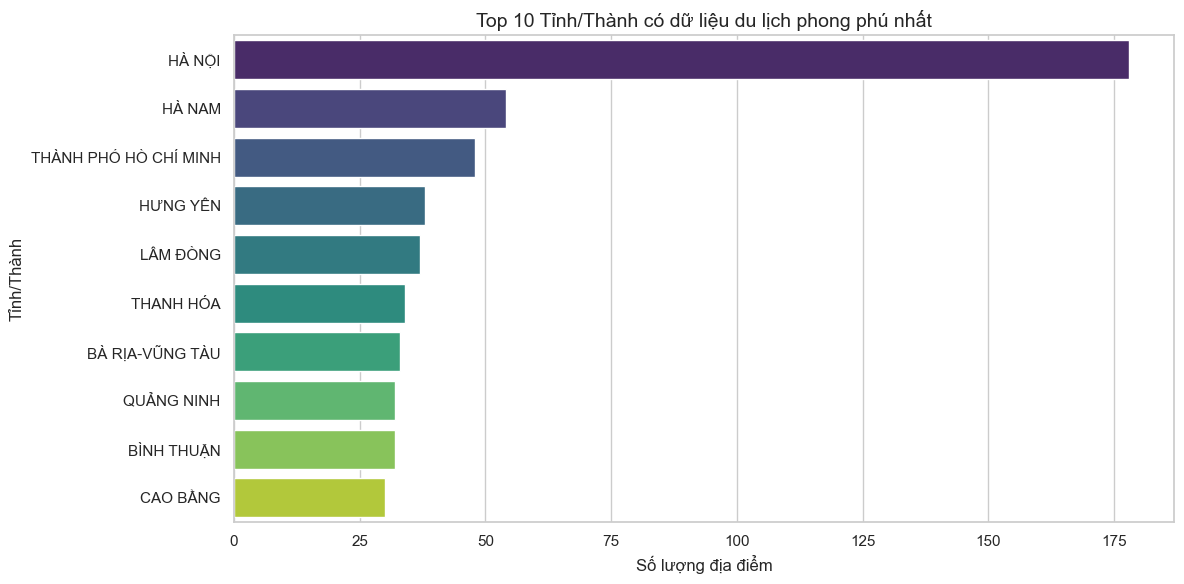

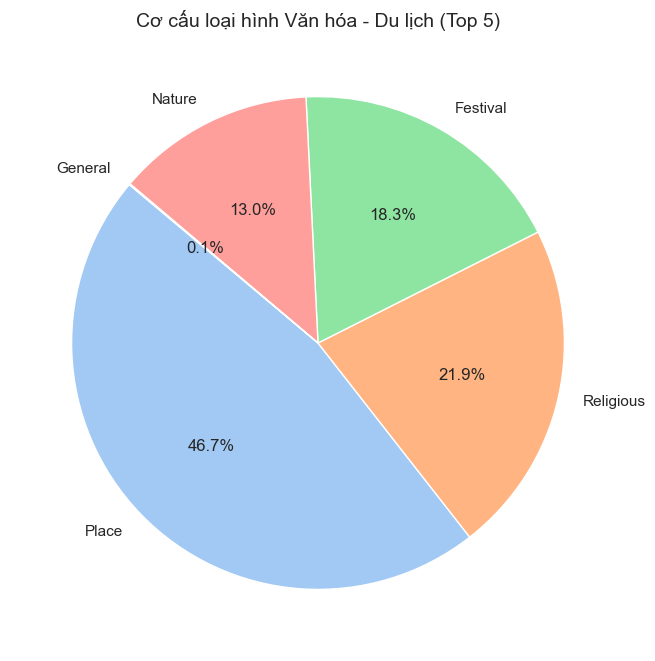

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CẤU HÌNH GIAO DIỆN BIỂU ĐỒ ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif' # Chọn font không lỗi tiếng Việt nếu có thể
plt.rcParams['figure.figsize'] = (14, 6)

def load_and_process_bus(file_path):
    """Xử lý dữ liệu xe buýt: Lấy thông tin tuyến và khoảng cách"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # 1. Lấy danh sách tuyến
        routes = data.get('Routes', [])
        df_bus = pd.DataFrame(routes)
        
        # Chỉ lấy các cột quan trọng
        df_bus = df_bus[['RouteNo', 'RouteName', 'Distance', 'TimeOfTrip']]
        
        # Chuyển đổi Distance sang km (giả sử dữ liệu gốc là mét)
        df_bus['Distance_KM'] = df_bus['Distance'] / 1000
        
        print(f"✅ Đã tải {len(df_bus)} tuyến xe buýt.")
        return df_bus
    except Exception as e:
        print(f"❌ Lỗi tải Bus: {e}")
        return pd.DataFrame()

def load_and_process_tourism(file_path):
    """Xử lý dữ liệu du lịch: Flatten (làm phẳng) cấu trúc lồng nhau"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Dữ liệu nằm trong key 'Provinces', mỗi tỉnh có danh sách 'items'
        provinces = data.get('Provinces', [])
        
        all_spots = []
        for prov in provinces:
            prov_name = prov.get('name', 'Unknown')
            items = prov.get('items', [])
            for item in items:
                all_spots.append({
                    'Province': prov_name,
                    'SpotName': item.get('name'),
                    'Type': item.get('type', 'Khác'), # Loại hình (Di tích, Lễ hội...)
                    'Content_Len': len(item.get('content', ''))
                })
                
        df_tour = pd.DataFrame(all_spots)
        print(f"✅ Đã tải {len(df_tour)} địa điểm du lịch từ {len(provinces)} tỉnh/thành.")
        return df_tour
    except Exception as e:
        print(f"❌ Lỗi tải Tourism: {e}")
        return pd.DataFrame()

# --- MAIN PROCESS ---
print("--- BẮT ĐẦU XỬ LÝ DỮ LIỆU CHO POSTER ---")

# 1. Load Data
df_bus = load_and_process_bus('../data/hcm_bus_final.json')
df_tour = load_and_process_tourism('../data/VanHoaVaDuLichVN_Full_Img.json')

# 2. Hiển thị bảng thống kê (Copy cái này vào Poster phần Dataset)
print("\n--- [BUS DATA SAMPLE] ---")
print(df_bus[['RouteNo', 'RouteName', 'Distance_KM']].head(5).to_markdown(index=False))

print("\n--- [TOURISM DATA SAMPLE] ---")
print(df_tour[['Province', 'SpotName', 'Type']].head(5).to_markdown(index=False))

print("\n--- [THỐNG KÊ TỔNG QUAN] ---")
print(f"Tổng số tuyến xe buýt: {len(df_bus)}")
print(f"Khoảng cách trung bình: {df_bus['Distance_KM'].mean():.2f} km")
print(f"Tổng số địa điểm du lịch: {len(df_tour)}")
print(f"Số lượng loại hình du lịch: {df_tour['Type'].nunique()}")

# 3. VẼ BIỂU ĐỒ (Lưu thành file ảnh để chèn Poster)

# --- Biểu đồ 1: Phân bố khoảng cách các tuyến xe buýt ---
plt.figure(figsize=(12, 6))
sns.histplot(data=df_bus, x='Distance_KM', bins=20, kde=True, color='skyblue')
plt.title('Phân bố độ dài lộ trình xe buýt TP.HCM (Distribution of Bus Route Distances)', fontsize=14)
plt.xlabel('Khoảng cách (km)')
plt.ylabel('Số lượng tuyến')
plt.savefig('chart_bus_distance.png', dpi=300) # Lưu ảnh chất lượng cao
print("\n📸 Đã lưu biểu đồ: chart_bus_distance.png")

# --- Biểu đồ 2: Top 10 Tỉnh thành có nhiều địa điểm du lịch nhất ---
if not df_tour.empty:
    top_provinces = df_tour['Province'].value_counts().head(10).reset_index()
    top_provinces.columns = ['Province', 'Count']
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_provinces, x='Count', y='Province', palette='viridis')
    plt.title('Top 10 Tỉnh/Thành có dữ liệu du lịch phong phú nhất', fontsize=14)
    plt.xlabel('Số lượng địa điểm')
    plt.ylabel('Tỉnh/Thành')
    plt.tight_layout()
    plt.savefig('chart_tourism_stats.png', dpi=300)
    print("📸 Đã lưu biểu đồ: chart_tourism_stats.png")

# --- Biểu đồ 3: Phân loại loại hình du lịch (Pie Chart) ---
if not df_tour.empty:
    type_counts = df_tour['Type'].value_counts().head(5) # Lấy top 5 loại hình
    plt.figure(figsize=(8, 8))
    plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Cơ cấu loại hình Văn hóa - Du lịch (Top 5)', fontsize=14)
    plt.savefig('chart_tourism_types.png', dpi=300)
    print("📸 Đã lưu biểu đồ: chart_tourism_types.png")

print("--- HOÀN TẤT ---")